Iter    0  beta[0]=0.1000  beta[-1]=0.1082  avg cost=-0.2300
Iter   20  beta[0]=0.1000  beta[-1]=0.2825  avg cost=-0.2367
Iter   40  beta[0]=0.1000  beta[-1]=0.4539  avg cost=-0.2567
Iter   60  beta[0]=0.1000  beta[-1]=0.6160  avg cost=-0.2433
Iter   80  beta[0]=0.1000  beta[-1]=0.7794  avg cost=-0.2800
Iter  100  beta[0]=0.1000  beta[-1]=0.9326  avg cost=-0.3100
Iter  120  beta[0]=0.1000  beta[-1]=1.0772  avg cost=-0.4067
Iter  140  beta[0]=0.1000  beta[-1]=1.2183  avg cost=-0.3533
Iter  160  beta[0]=0.1000  beta[-1]=1.3520  avg cost=-0.4067
Iter  180  beta[0]=0.1000  beta[-1]=1.4790  avg cost=-0.3733
Iter  200  beta[0]=0.1000  beta[-1]=1.5974  avg cost=-0.4167
Iter  220  beta[0]=0.1000  beta[-1]=1.7080  avg cost=-0.4333
Iter  240  beta[0]=0.1000  beta[-1]=1.8087  avg cost=-0.4567
Iter  260  beta[0]=0.1000  beta[-1]=1.9069  avg cost=-0.4700
Iter  280  beta[0]=0.1000  beta[-1]=1.9990  avg cost=-0.4433
Iter  300  beta[0]=0.1000  beta[-1]=2.0857  avg cost=-0.4800
Iter  320  beta[0]=0.100

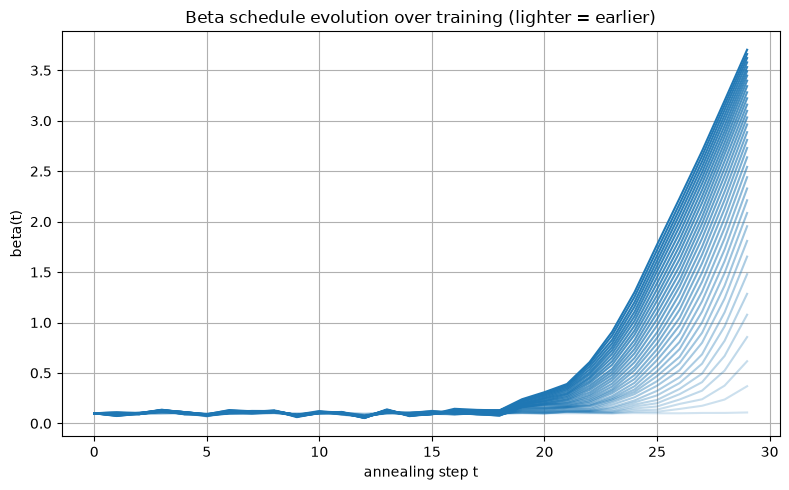

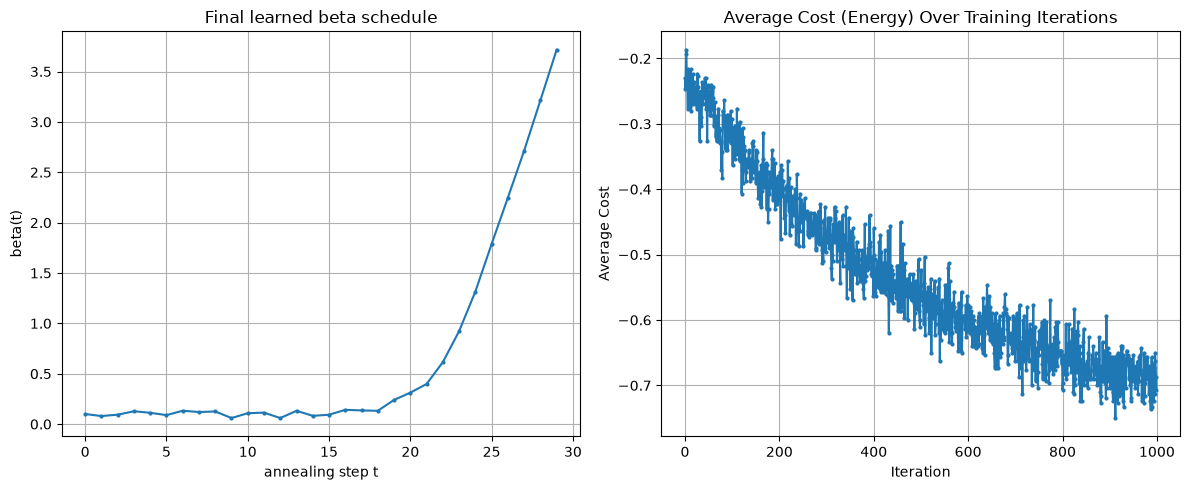

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from Functions import (laydowncoordinates, compute_A, M, Mhat, energy, valid_fold)
from Functions import (generate_all_proposals, generate_legal_neighbors, barker,
                        cost_per_sample, RL_trajectory, grad_expectedcost, update_beta)


def RL_trajectory_schedule(d0, Gamma, A, H, beta_schedule, num_time_steps):
    d = d0.copy()
    E_current = cost_per_sample(Gamma, A, H, d)
    grad_logP = np.zeros(num_time_steps)  # per-step gradient, not a scalar

    for t in range(num_time_steps):
        neighbors = generate_legal_neighbors(d)
        if len(neighbors) == 0:
            break

        beta_t = beta_schedule[t]
        j = np.random.randint(len(neighbors))
        d_prime = neighbors[j]
        E_prime = cost_per_sample(Gamma, A, H, d_prime)
        deltaE = E_prime - E_current

        A_accept = barker(deltaE, beta_t)
        u = np.random.uniform(0, 1)
        if u < A_accept:
            grad_logP[t] = -deltaE / (1 + np.exp(-beta_t * deltaE))
            d = d_prime
            E_current = E_prime
        else:
            grad_logP[t] = deltaE / (1 + np.exp(beta_t * deltaE))

    return d, E_current, grad_logP


def grad_expectedcost_schedule(d0, Gamma, beta_schedule, num_time_steps=1, num_independent_experiments=10):
    H = 1
    A = compute_A(Gamma)
    costs = np.zeros(num_independent_experiments)
    grad_matrix = np.zeros((num_independent_experiments, num_time_steps))

    for i in range(num_independent_experiments):
        d_final, E_final, grad_logP = RL_trajectory_schedule(d0, Gamma, A, H, beta_schedule, num_time_steps)
        costs[i] = E_final
        grad_matrix[i] = grad_logP

    baseline = np.mean(costs)
    grad_beta_schedule = np.mean((costs - baseline)[:, None] * grad_matrix, axis=0)

    return costs, grad_beta_schedule


def update_beta_schedule(beta_schedule, grad_beta_schedule, learning_rate):
    beta_schedule = beta_schedule - learning_rate * grad_beta_schedule
    return np.clip(beta_schedule, 0.0, None)


H = 1
P = 0
# Gamma = [P, P, H, P, H, P, P, P, P, H, P, H, H, P, H, P]  # 16-bead sequence
# d0 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Gamma = [H,P,P,H]  # 16-bead sequence
d0 = [1, 1, 1]

num_time_steps = 30
num_independent_experiments = 300
learning_rate = 0.1
num_iterations = 1000

cost_history = []
schedule_snapshots = []
snapshot_every = 30

beta_schedule = np.full(num_time_steps, 0.1)  # initialize BEFORE the loop

for iteration in range(num_iterations):
    costs, grad = grad_expectedcost_schedule(d0, Gamma, beta_schedule, num_time_steps, num_independent_experiments)
    beta_schedule = update_beta_schedule(beta_schedule, grad, learning_rate)
    cost_history.append(np.mean(costs))

    if iteration % snapshot_every == 0:
        schedule_snapshots.append(beta_schedule.copy())

    if iteration % 20 == 0:
        print(f"Iter {iteration:4d}  beta[0]={beta_schedule[0]:.4f}  "
              f"beta[-1]={beta_schedule[-1]:.4f}  avg cost={np.mean(costs):.4f}")


# schedule evolution over training
plt.figure(figsize=(8, 5))
for i, snap in enumerate(schedule_snapshots):
    alpha = 0.2 + 0.8 * (i / max(len(schedule_snapshots) - 1, 1))
    plt.plot(snap, color='C0', alpha=alpha)
plt.xlabel("annealing step t")
plt.ylabel("beta(t)")
plt.title("Beta schedule evolution over training (lighter = earlier)")
plt.grid(True)
plt.tight_layout()
plt.show()

# final schedule + cost convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(beta_schedule, marker='o', markersize=2)
axes[0].set_title("Final learned beta schedule")
axes[0].set_xlabel("annealing step t")
axes[0].set_ylabel("beta(t)")
axes[0].grid(True)

axes[1].plot(cost_history, marker='o', markersize=2)
axes[1].set_title("Average Cost (Energy) Over Training Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Average Cost")
axes[1].grid(True)

plt.tight_layout()
plt.show()